In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib  

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("Libraries imported successfully ")

Libraries imported successfully 


In [17]:
df = pd.read_csv('../data/raw/diabetes.csv')

print(f"Raw dataset shape : {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Raw dataset shape : (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
# STEP 1: Replace impossible zero values with NaN

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy() 

for col in zero_columns:
    zero_count = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, np.nan)
    print(f"  {col:25s}: {zero_count} zeros replaced with NaN")

print(f"\nMissing values after replacement:")
print(df_clean.isnull().sum())

  Glucose                  : 5 zeros replaced with NaN
  BloodPressure            : 35 zeros replaced with NaN
  SkinThickness            : 227 zeros replaced with NaN
  Insulin                  : 374 zeros replaced with NaN
  BMI                      : 11 zeros replaced with NaN

Missing values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [19]:
# STEP 2: Fill missing values with MEDIAN


print("Imputing missing values using GROUP MEDIAN (by Outcome):\n")

for col in zero_columns:
    median_by_group = df_clean.groupby('Outcome')[col].median()
    print(f"  {col} median → Non-Diabetic: {median_by_group[0]:.1f} | Diabetic: {median_by_group[1]:.1f}")


    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

print(f"\nMissing values after imputation:")
print(df_clean.isnull().sum())
print("\n No more missing values!")

Imputing missing values using GROUP MEDIAN (by Outcome):

  Glucose median → Non-Diabetic: 107.0 | Diabetic: 140.0
  BloodPressure median → Non-Diabetic: 70.0 | Diabetic: 74.5
  SkinThickness median → Non-Diabetic: 27.0 | Diabetic: 32.0
  Insulin median → Non-Diabetic: 102.5 | Diabetic: 169.5
  BMI median → Non-Diabetic: 30.1 | Diabetic: 34.3

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 No more missing values!


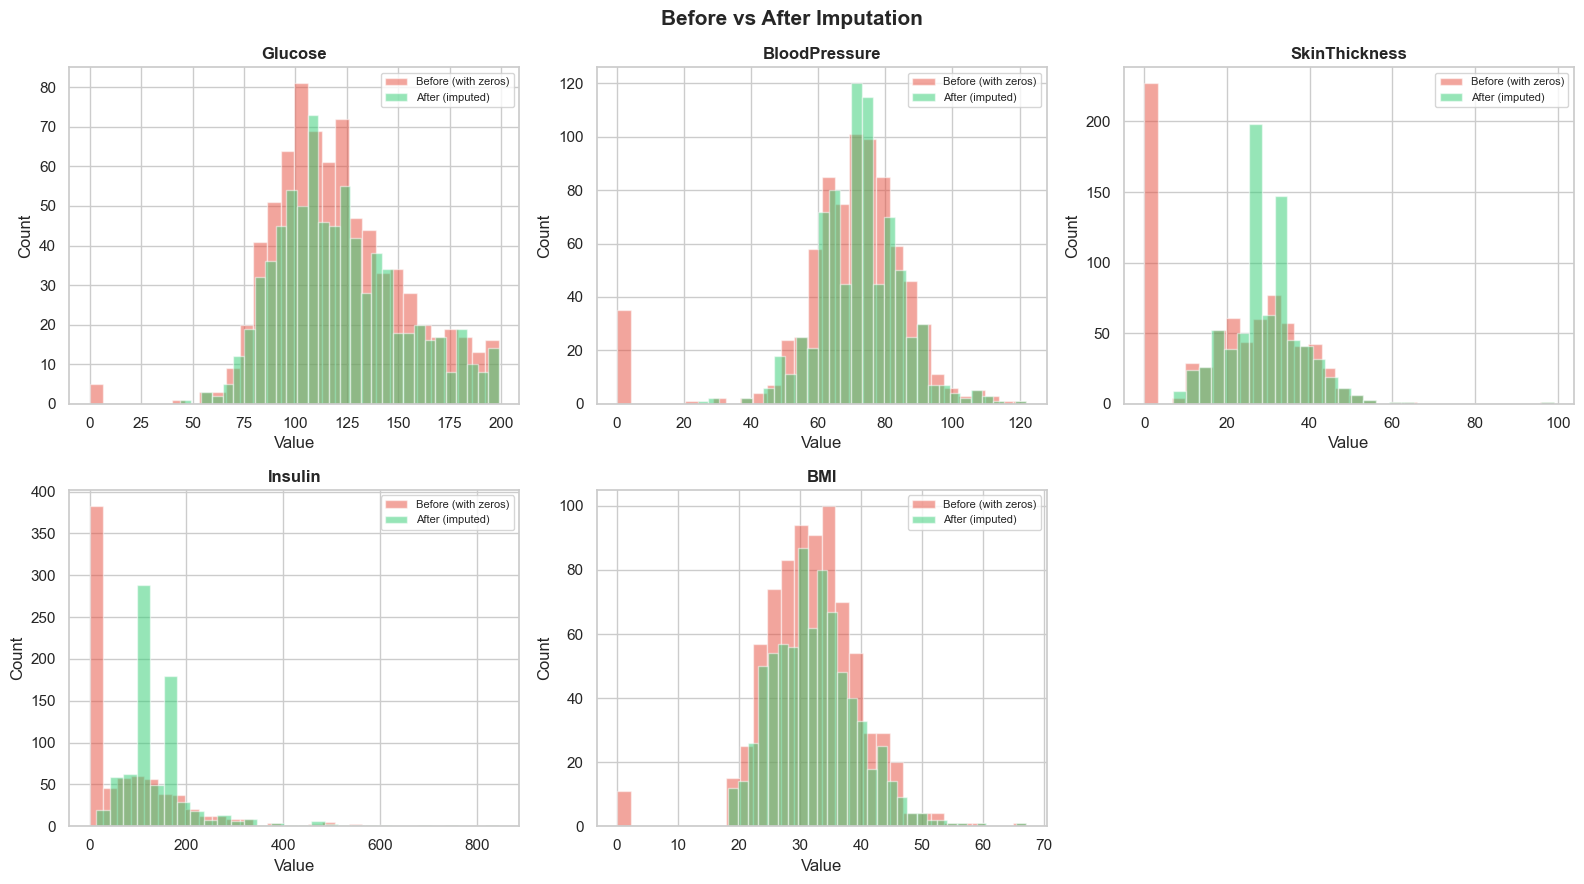

Plot saved to reports/07_before_after_imputation.png


In [20]:
# Visualize: Before vs After imputation for key columns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for i, col in enumerate(check_cols):
   
    axes[i].hist(df[col], bins=30, alpha=0.5, color='#e74c3c',
                 label='Before (with zeros)', edgecolor='white')
   
    axes[i].hist(df_clean[col], bins=30, alpha=0.5, color='#2ecc71',
                 label='After (imputed)', edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)

plt.suptitle('Before vs After Imputation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/07_before_after_imputation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/07_before_after_imputation.png")

In [21]:
# STEP 3: Handle Outliers using IQR Capping

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

df_clean2 = df_clean.copy()

print("Outlier Capping using IQR method:\n")

for col in features:
    Q1 = df_clean2[col].quantile(0.25)  
    Q3 = df_clean2[col].quantile(0.75)   
    IQR = Q3 - Q1                        

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_clean2[col] < lower_bound) | (df_clean2[col] > upper_bound)).sum()

    df_clean2[col] = df_clean2[col].clip(lower=lower_bound, upper=upper_bound)

    print(f"  {col:28s}: {outliers:3d} outliers capped "
          f"[{lower_bound:.1f} — {upper_bound:.1f}]")

print("\nOutlier capping complete!")

Outlier Capping using IQR method:

  Pregnancies                 :   4 outliers capped [-6.5 — 13.5]
  Glucose                     :   0 outliers capped [39.0 — 201.0]
  BloodPressure               :  14 outliers capped [40.0 — 104.0]
  SkinThickness               :  87 outliers capped [14.5 — 42.5]
  Insulin                     :  51 outliers capped [2.0 — 270.0]
  BMI                         :   8 outliers capped [13.8 — 50.2]
  DiabetesPedigreeFunction    :  29 outliers capped [-0.3 — 1.2]
  Age                         :   9 outliers capped [-1.5 — 66.5]

Outlier capping complete!


In [22]:
# STEP 4: Feature Engineering

df_feat = df_clean2.copy()

def bmi_category(bmi):
    if bmi < 18.5:
        return 0   
    elif bmi < 25:
        return 1   
    elif bmi < 30:
        return 2   
    else:
        return 3   

df_feat['BMI_Category'] = df_feat['BMI'].apply(bmi_category)

def age_group(age):
    if age < 30:
        return 0   
    elif age < 45:
        return 1   
    else:
        return 2   

df_feat['Age_Group'] = df_feat['Age'].apply(age_group)

def glucose_level(glucose):
    if glucose < 100:
        return 0   
    elif glucose < 126:
        return 1   
    else:
        return 2   
    
df_feat['Glucose_Level'] = df_feat['Glucose'].apply(glucose_level)

df_feat['Insulin_Resistance'] = df_feat['BMI'] * df_feat['Glucose'] / 1000

print("New features added:")
print(f"   BMI_Category      : {df_feat['BMI_Category'].value_counts().to_dict()}")
print(f"   Age_Group         : {df_feat['Age_Group'].value_counts().to_dict()}")
print(f"   Glucose_Level     : {df_feat['Glucose_Level'].value_counts().to_dict()}")
print(f"   Insulin_Resistance: min={df_feat['Insulin_Resistance'].min():.2f}, "
      f"max={df_feat['Insulin_Resistance'].max():.2f}")

print(f"\nDataset shape after feature engineering: {df_feat.shape}")
df_feat.head()

New features added:
   BMI_Category      : {3: 483, 2: 179, 1: 102, 0: 4}
   Age_Group         : {0: 396, 1: 239, 2: 133}
   Glucose_Level     : {2: 299, 1: 277, 0: 192}
   Insulin_Resistance: min=1.10, max=9.04

Dataset shape after feature engineering: (768, 13)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level,Insulin_Resistance
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,3,2,2,4.9728
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,2,1,0,2.2610
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,1,1,2,4.2639
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,2,0,0,2.5009
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,3,1,2,5.9047


In [23]:
# STEP 5: Train-Test Split

X = df_feat.drop('Outcome', axis=1)   
y = df_feat['Outcome']                 

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"Feature columns    : {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,      
    stratify=y            
)

print(f"\nAfter Split:")
print(f"  X_train : {X_train.shape}  | y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}   | y_test  : {y_test.shape}")
print(f"\nClass distribution in train set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Features (X) shape : (768, 12)
Target   (y) shape : (768,)
Feature columns    : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category', 'Age_Group', 'Glucose_Level', 'Insulin_Resistance']

After Split:
  X_train : (614, 12)  | y_train : (614,)
  X_test  : (154, 12)   | y_test  : (154,)

Class distribution in train set:
Outcome
0    400
1    214
Name: count, dtype: int64

Class distribution in test set:
Outcome
0    100
1     54
Name: count, dtype: int64


In [24]:
# STEP 6: Fix Class Imbalance using SMOTE

print("Before SMOTE:")
print(f"  Training set class distribution:")
print(f"  {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training set class distribution:")
unique, counts = np.unique(y_train_smote, return_counts=True)
print(f"  {dict(zip(unique, counts))}")
print(f"\n  X_train shape before SMOTE : {X_train.shape}")
print(f"  X_train shape after  SMOTE : {X_train_smote.shape}")
print(f"\n Classes are now balanced!")

Before SMOTE:
  Training set class distribution:
  {0: 400, 1: 214}

After SMOTE:
  Training set class distribution:
  {np.int64(0): np.int64(400), np.int64(1): np.int64(400)}

  X_train shape before SMOTE : (614, 12)
  X_train shape after  SMOTE : (800, 12)

 Classes are now balanced!


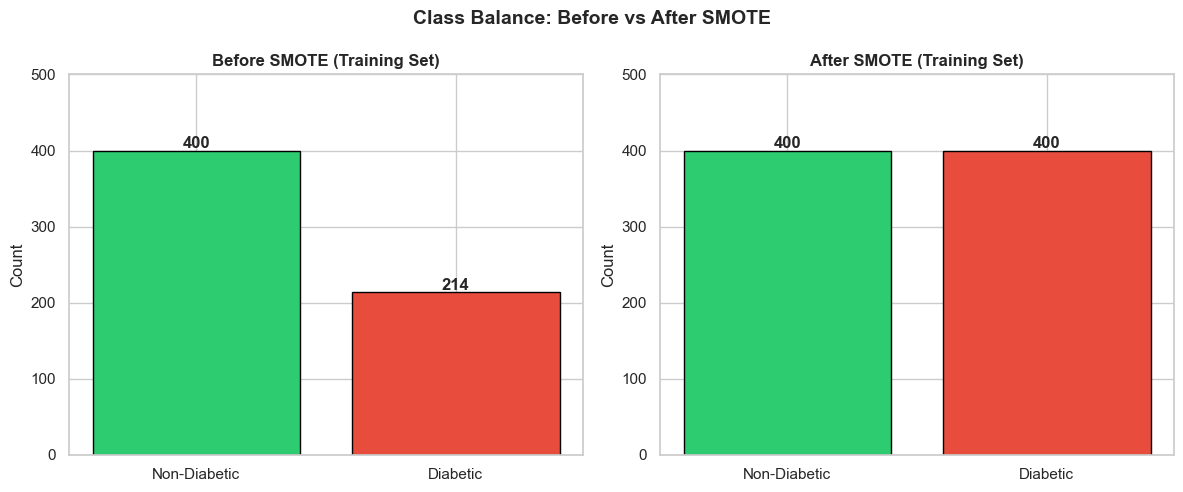

 Plot saved to reports/08_smote_balance.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before_counts = y_train.value_counts()
axes[0].bar(['Non-Diabetic', 'Diabetic'], before_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[0].set_title('Before SMOTE (Training Set)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 500)

after_counts = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Non-Diabetic', 'Diabetic'], after_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[1].set_title('After SMOTE (Training Set)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 500)

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to reports/08_smote_balance.png")

In [26]:
# STEP 7: Feature Scaling using StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Applied")
print(f"\nBefore scaling (first row of X_train):")
print(np.round(X_train_smote.iloc[0].values, 3))
print(f"\nAfter scaling (same row):")
print(np.round(X_train_scaled[0], 3))
print(f"\nScaled data stats (should be ~mean=0, std=1):")
print(f"  Mean : {X_train_scaled.mean():.6f}")
print(f"  Std  : {X_train_scaled.std():.6f}")

joblib.dump(scaler, '../models/scaler.pkl')
print(f"\n Scaler saved to models/scaler.pkl")

Feature Scaling Applied

Before scaling (first row of X_train):
[ 1.    90.    62.    14.5   43.    27.2    0.58  24.     2.     0.
  0.     2.448]

After scaling (same row):
[-0.922 -1.18  -0.96  -2.072 -1.712 -0.911  0.364 -0.879 -0.778 -0.917
 -1.579 -1.217]

Scaled data stats (should be ~mean=0, std=1):
  Mean : 0.000000
  Std  : 1.000000

 Scaler saved to models/scaler.pkl


In [27]:
import os

os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/X_train.npy', X_train_scaled)
np.save('../data/processed/X_test.npy', X_test_scaled)
np.save('../data/processed/y_train.npy', y_train_smote)
np.save('../data/processed/y_test.npy', y_test.values)

df_feat.to_csv('../data/processed/diabetes_cleaned.csv', index=False)

feature_names = list(X.columns)
joblib.dump(feature_names, '../models/feature_names.pkl')

print("All processed data saved")
print(f"\nSaved files:")
print(f"   data/processed/X_train.npy       → {X_train_scaled.shape}")
print(f"   data/processed/X_test.npy        → {X_test_scaled.shape}")
print(f"   data/processed/y_train.npy       → {y_train_smote.shape}")
print(f"   data/processed/y_test.npy        → {y_test.shape}")
print(f"   data/processed/diabetes_cleaned.csv")
print(f"   models/scaler.pkl")
print(f"   models/feature_names.pkl")

All processed data saved

Saved files:
   data/processed/X_train.npy       → (800, 12)
   data/processed/X_test.npy        → (154, 12)
   data/processed/y_train.npy       → (800,)
   data/processed/y_test.npy        → (154,)
   data/processed/diabetes_cleaned.csv
   models/scaler.pkl
   models/feature_names.pkl


In [29]:

print("             PREPROCESSING SUMMARY")

print()
print("Steps completed:")
print("   Step 1: Hidden zeros replaced with NaN")
print("   Step 2: Missing values imputed (group median)")
print("   Step 3: Outliers capped using IQR method")
print("   Step 4: 4 new features engineered")
print("   Step 5: Train-test split (80/20, stratified)")
print("   Step 6: Class imbalance fixed with SMOTE")
print("   Step 7: Features scaled with StandardScaler")
print()
print("Data shapes going into Phase 5:")
print(f"  X_train (scaled) : {X_train_scaled.shape}")
print(f"  X_test  (scaled) : {X_test_scaled.shape}")
print(f"  y_train (SMOTE)  : {y_train_smote.shape}")
print(f"  y_test           : {y_test.shape}")
print()
print("  Ready for Phase 5: Model Training!")


             PREPROCESSING SUMMARY

Steps completed:
   Step 1: Hidden zeros replaced with NaN
   Step 2: Missing values imputed (group median)
   Step 3: Outliers capped using IQR method
   Step 4: 4 new features engineered
   Step 5: Train-test split (80/20, stratified)
   Step 6: Class imbalance fixed with SMOTE
   Step 7: Features scaled with StandardScaler

Data shapes going into Phase 5:
  X_train (scaled) : (800, 12)
  X_test  (scaled) : (154, 12)
  y_train (SMOTE)  : (800,)
  y_test           : (154,)

  Ready for Phase 5: Model Training!
